# **Sparse Variational Gaussian Processes Baseline All Sensors**

## **Libraries Import**

In [1]:
from preprocessing import CMAPSS, preprocessing, create_windows
from Models import FirstBaseline
from Training import train
from Testing import test
from dataloading import load_data
from torch.utils.data import DataLoader
import torch
from torch import nn
from GP import run_svgp_pipeline, plot_predictions_gp, plot_errors, plot_uncertainty

### **GPU check**

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.11.0+cu128
CUDA available: True
Current GPU: NVIDIA GeForce RTX 4060 Ti
GPU count: 1
MPS available: False


### **Data load**

In [2]:
# data loading
filename = '../N-CMAPSS_DS02-006.h5'
W, X_s, X_v, T, Y, A, W_var, X_s_var, X_v_var, T_var, A_var, train_df, test_df = load_data(filename)
print(f"Unique units in train_df: {train_df['unit'].unique()}")
print(f"Shape of train_df: {train_df.shape}")
train_df.head()



Operation time (min):  0.011197916666666667

W shape: (6517190, 4)
X_s shape: (6517190, 14)
X_v shape: (6517190, 14)
T shape: (6517190, 10)
A shape: (6517190, 4)
Unique units in train_df: [ 2  5 10 16 18 20]
Shape of train_df: (5263447, 37)


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,W25,W31,W32,W48,W50,SmFan,SmLPC,SmHPC,phi,RUL
0,2,1.0,3,1,10005.0,0.448497,76.903748,502.420918,600.148034,1438.498187,...,228.487065,26.498785,15.899271,215.844851,228.411666,16.648833,9.898130,25.376144,41.893990,74.0
1,2,1.0,3,1,10013.0,0.447741,76.903748,502.326114,600.055894,1438.350208,...,228.383505,26.486552,15.891931,215.745634,228.307014,16.639222,9.904927,25.380549,41.884434,74.0
2,2,1.0,3,1,10017.0,0.448938,77.079529,502.416067,600.210756,1439.109101,...,228.661083,26.519340,15.911604,216.019054,228.592279,16.649823,9.923503,25.318848,41.953848,74.0
3,2,1.0,3,1,10024.0,0.449883,77.079529,502.469893,600.369717,1439.240230,...,228.768625,26.532044,15.919226,216.121238,228.702994,16.653812,9.905518,25.361981,41.914342,74.0
4,2,1.0,3,1,10031.0,0.449379,77.079529,502.401271,600.298227,1439.064004,...,228.653631,26.518460,15.911076,216.008509,228.584788,16.649031,9.897465,25.363994,41.911503,74.0


In [6]:
print(f"Unique units in test_df: {test_df['unit'].unique()}")
print(f"Shape of test_df: {test_df.shape}")
test_df.head()

Unique units in test_df: [11 14 15]
Shape of test_df: (1253743, 37)


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,W25,W31,W32,W48,W50,SmFan,SmLPC,SmHPC,phi,RUL
0,11,1.0,3,1,10014.0,0.457506,77.25531,503.176696,601.369822,1441.086963,...,229.763207,26.649529,15.989717,217.085529,229.722454,16.745510,9.812495,25.345244,41.971419,58.0
1,11,1.0,3,1,10020.0,0.457947,77.25531,503.192949,601.381211,1441.055436,...,229.736365,26.646358,15.987815,217.058720,229.694212,16.751997,9.806257,25.346932,41.971470,58.0
2,11,1.0,3,1,10029.0,0.458451,77.25531,503.203187,601.392126,1441.063188,...,229.719527,26.644369,15.986621,217.043190,229.677650,16.758975,9.804009,25.348326,41.969940,58.0
3,11,1.0,3,1,10034.0,0.458136,77.25531,503.158580,601.348485,1440.964145,...,229.655911,26.636854,15.982113,216.981145,229.612403,16.755378,9.803649,25.352080,41.964794,58.0
4,11,1.0,3,1,10045.0,0.458010,77.25531,503.105629,601.285695,1440.852510,...,229.561414,26.625692,15.975415,216.890123,229.516137,16.753262,9.806697,25.351024,41.963540,58.0


### **Data preprocessing**

In [ ]:
features = W_var + X_s_var + X_v_var # features selection

X_train_scaled_df, X_test_scaled_df, Y_train, Y_test = preprocessing(True, train_df, test_df, features)
print("Preprocessing completed.")
print("Training set shape:", X_train_scaled_df.shape, "Training labels shape:", Y_train.shape)
print("Testing set shape:", X_test_scaled_df.shape, "Testing labels shape:", Y_test.shape)

✓ Data Normalization

Preprocessing completed.
Training set shape: (5263447, 35) Training labels shape: (5263447,)
Testing set shape: (1253743, 35) Testing labels shape: (1253743,)


### **Window processing**

In [ ]:
train_engine_df = X_train_scaled_df[X_train_scaled_df['unit'] != 18]
val_engine_df   = X_train_scaled_df[X_train_scaled_df['unit'] == 18]

print(f"Shape of train_engine_df: {train_engine_df.shape} and engine units: {train_engine_df['unit'].unique()}")
print(f"Shape of val_engine_df: {val_engine_df.shape} and engine units: {val_engine_df['unit'].unique()}")
print(f"Shape of X_test_scaled_df: {X_test_scaled_df.shape} and engine units: {X_test_scaled_df['unit'].unique()}")

X_windows_train, Y_windows_train = create_windows(train_engine_df, features, window_size=50, stride=15)
X_windows_val, Y_windows_val     = create_windows(val_engine_df, features, window_size=50, stride=15)
X_windows_test, Y_windows_test = create_windows(X_test_scaled_df, features, window_size=50, stride=15)

print("X train normalized windows shape:",X_windows_train.shape,"\n Y train windows  shape:" , Y_windows_train.shape)  
print("X val windows shape:",X_windows_val.shape,"\n Y val windows  shape:" , Y_windows_val.shape) # engine (18) for validating
print("X test windows shape:",X_windows_test.shape,"\n Y test windows  shape:" , Y_windows_test.shape) 


Shape of train_engine_df: (4372728, 35) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 35) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 35) and engine units: [11 14 15]
X train normalized windows shape: (291501, 50, 32) 
 Y train windows  shape: (291501,)
X val windows shape: (59378, 50, 32) 
 Y val windows  shape: (59378,)
X test windows shape: (83574, 50, 32) 
 Y test windows  shape: (83574,)


## **Training & Testing**

#### **Train with physical sensors only**

In [9]:
X_train_gp = X_windows_train.mean(axis=1)
X_val_gp   = X_windows_val.mean(axis=1)
X_test_gp  = X_windows_test.mean(axis=1)

results = run_svgp_pipeline(
    X_train_gp, Y_windows_train,
    X_val_gp, Y_windows_val,
    X_test_gp, Y_windows_test
)

TRAINING SVGP MODEL
Training samples: 291501
Inducing points: 400
Epoch    0 | Train ELBO loss: 419.2654 | Val RMSE: 20.1174
Epoch    5 | Train ELBO loss: 38.9762 | Val RMSE: 12.2806
Epoch   10 | Train ELBO loss: 19.3387 | Val RMSE: 10.0001
Epoch   15 | Train ELBO loss: 13.2021 | Val RMSE: 8.4914
Epoch   20 | Train ELBO loss: 10.0365 | Val RMSE: 7.9087
Epoch   25 | Train ELBO loss: 8.1186 | Val RMSE: 7.4946
Epoch   30 | Train ELBO loss: 6.8490 | Val RMSE: 6.8260
Epoch   35 | Train ELBO loss: 5.8822 | Val RMSE: 7.0267
Epoch   40 | Train ELBO loss: 5.3163 | Val RMSE: 6.9421
Epoch   45 | Train ELBO loss: 4.7863 | Val RMSE: 6.5158
Epoch   50 | Train ELBO loss: 4.4279 | Val RMSE: 6.4341
Epoch   55 | Train ELBO loss: 4.1898 | Val RMSE: 6.8317
Epoch   60 | Train ELBO loss: 4.0239 | Val RMSE: 6.4248
Epoch   65 | Train ELBO loss: 3.9193 | Val RMSE: 6.1703
Epoch   70 | Train ELBO loss: 3.8335 | Val RMSE: 6.3498
Epoch   75 | Train ELBO loss: 3.7796 | Val RMSE: 6.4395
Epoch   80 | Train ELBO loss:

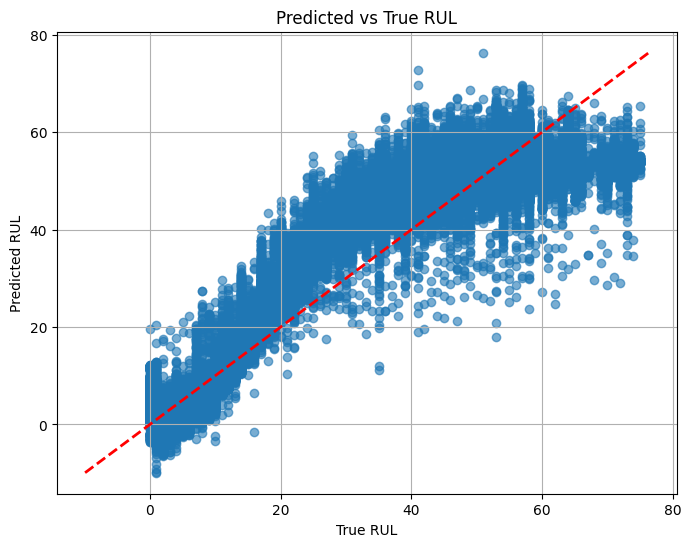

In [10]:
plot_predictions_gp(Y_windows_test, results['test_mean'])

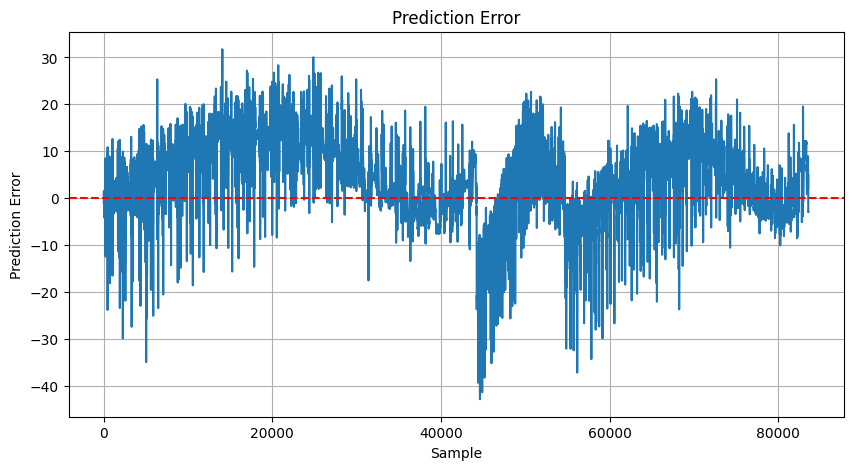

In [11]:
plot_errors(Y_windows_test, results['test_mean'])

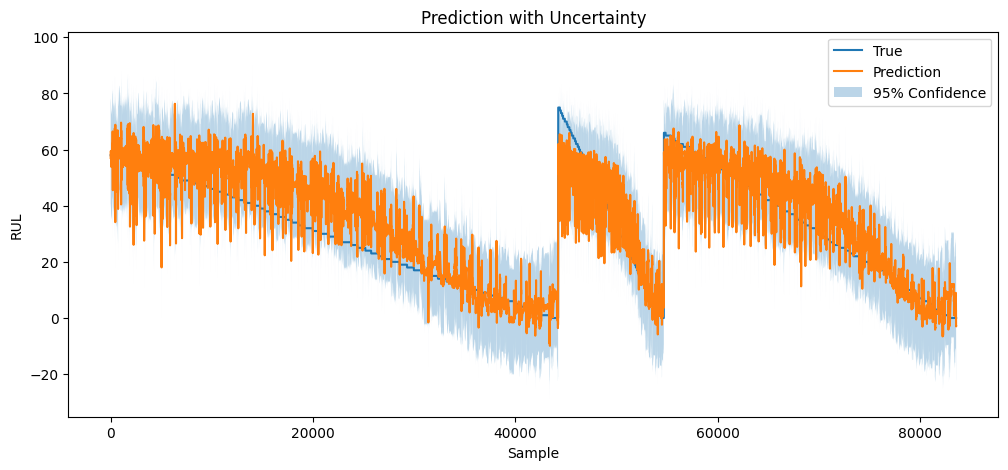

In [12]:
plot_uncertainty(
    Y_windows_test,
    results['test_mean'],
    results['test_std']
)

#### **Train with physical & virtual sensors**

In [25]:
X_train_gp = X_windows_train.mean(axis=1)
X_val_gp   = X_windows_val.mean(axis=1)
X_test_gp  = X_windows_test.mean(axis=1)

results = run_svgp_pipeline(
    X_train_gp, Y_windows_train,
    X_val_gp, Y_windows_val,
    X_test_gp, Y_windows_test
)

TRAINING SVGP MODEL
Training samples: 291501
Inducing points: 400
Epoch    0 | Train ELBO loss: 412.9360 | Val RMSE: 19.9159
Epoch    5 | Train ELBO loss: 33.8450 | Val RMSE: 11.9331
Epoch   10 | Train ELBO loss: 18.0005 | Val RMSE: 9.0625
Epoch   15 | Train ELBO loss: 12.0728 | Val RMSE: 8.3359
Epoch   20 | Train ELBO loss: 9.2922 | Val RMSE: 7.0944
Epoch   25 | Train ELBO loss: 7.6340 | Val RMSE: 7.0392
Epoch   30 | Train ELBO loss: 6.5302 | Val RMSE: 6.5060
Epoch   35 | Train ELBO loss: 5.6676 | Val RMSE: 6.5751
Epoch   40 | Train ELBO loss: 5.0795 | Val RMSE: 6.9049
Epoch   45 | Train ELBO loss: 4.6103 | Val RMSE: 6.1201
Epoch   50 | Train ELBO loss: 4.3347 | Val RMSE: 6.0427
Epoch   55 | Train ELBO loss: 4.0824 | Val RMSE: 6.6616
Epoch   60 | Train ELBO loss: 3.9323 | Val RMSE: 6.2544
Epoch   65 | Train ELBO loss: 3.8332 | Val RMSE: 6.2586
Epoch   70 | Train ELBO loss: 3.7613 | Val RMSE: 6.0830
Epoch   75 | Train ELBO loss: 3.7208 | Val RMSE: 6.0331
Epoch   80 | Train ELBO loss: 3

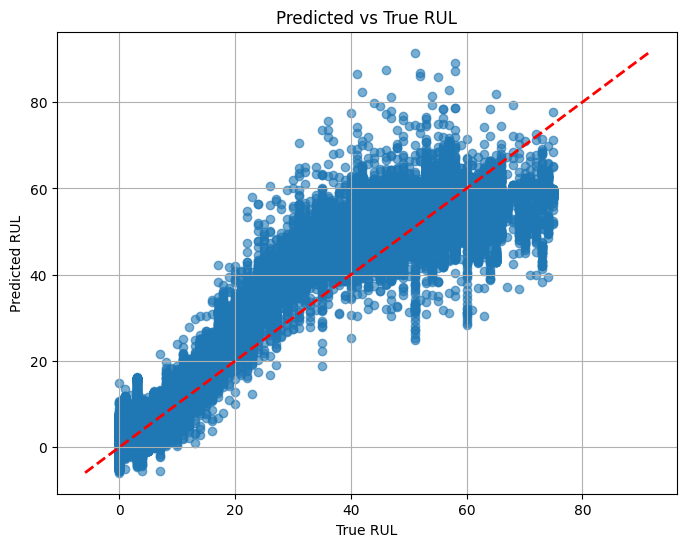

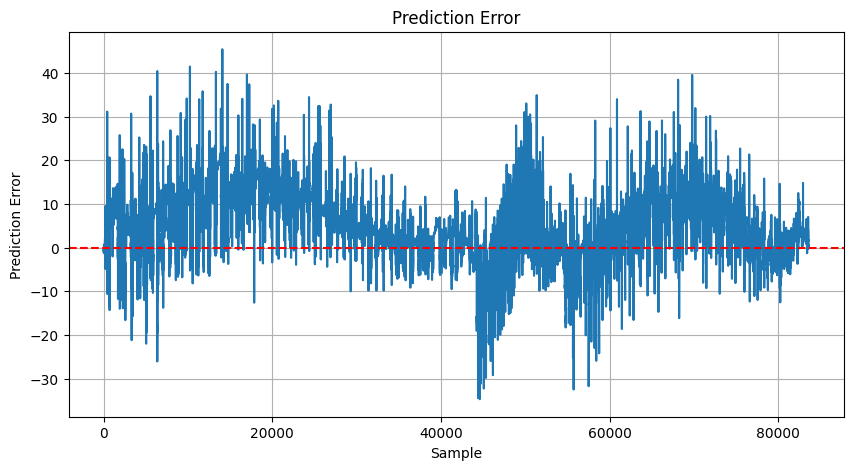

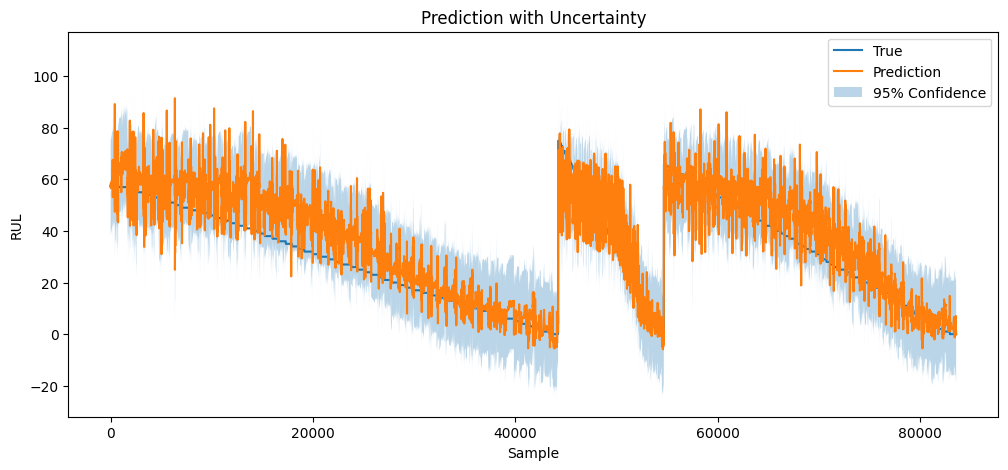

In [26]:
plot_predictions_gp(Y_windows_test, results['test_mean'])
plot_errors(Y_windows_test, results['test_mean'])
plot_uncertainty(
    Y_windows_test,
    results['test_mean'],
    results['test_std']
)

### **small search space**

Configuration: lr: 0.01, inducing_points: 400, batch_size: 512
num_inducing: 400
TRAINING SVGP MODEL
Training samples: 291501
Inducing points: 400
Epoch    0 | Train ELBO loss: 265.3234 | Val RMSE: 17.7280
Epoch    5 | Train ELBO loss: 17.9899 | Val RMSE: 9.5566
Epoch   10 | Train ELBO loss: 9.5381 | Val RMSE: 7.6547
Epoch   15 | Train ELBO loss: 6.6651 | Val RMSE: 7.0700
Epoch   20 | Train ELBO loss: 5.2077 | Val RMSE: 6.8039
Epoch   25 | Train ELBO loss: 4.4229 | Val RMSE: 7.7957
Epoch   30 | Train ELBO loss: 4.0077 | Val RMSE: 7.1308
Epoch   35 | Train ELBO loss: 3.8097 | Val RMSE: 7.6833
Epoch   40 | Train ELBO loss: 3.7324 | Val RMSE: 6.8554
Epoch   45 | Train ELBO loss: 3.7063 | Val RMSE: 6.1762
Epoch   50 | Train ELBO loss: 3.7030 | Val RMSE: 6.5163
Epoch   55 | Train ELBO loss: 3.7050 | Val RMSE: 6.6537
Epoch   60 | Train ELBO loss: 3.7033 | Val RMSE: 6.1184
Epoch   65 | Train ELBO loss: 3.7013 | Val RMSE: 7.2101
Epoch   70 | Train ELBO loss: 3.7022 | Val RMSE: 6.7477
Epoch   7

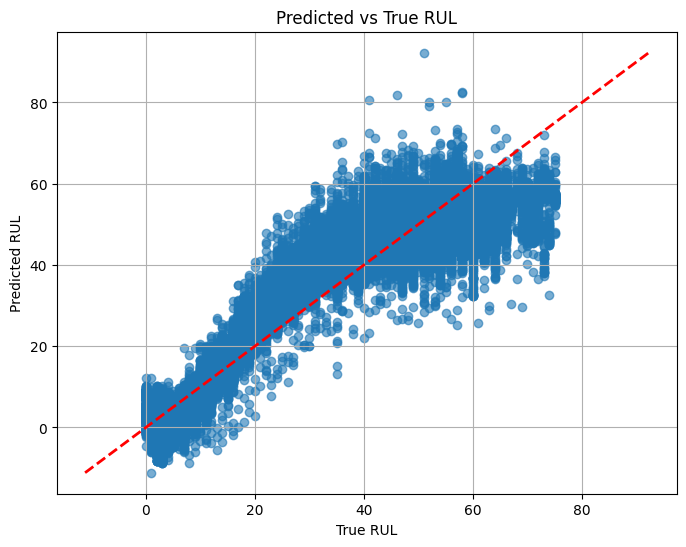

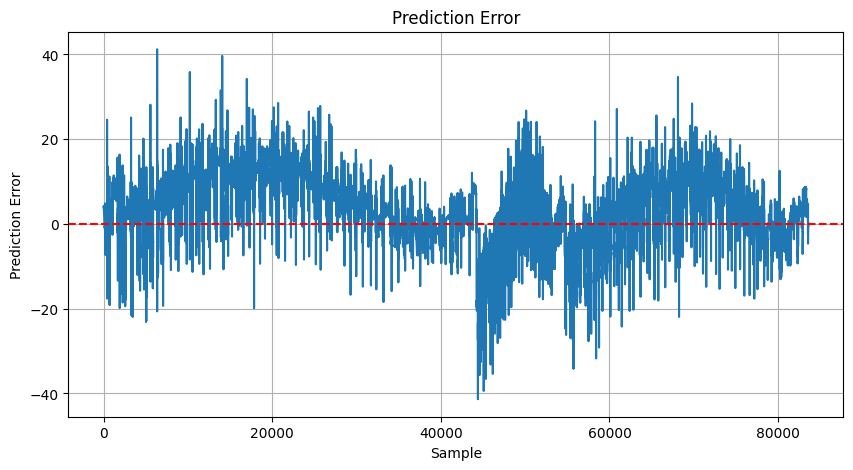

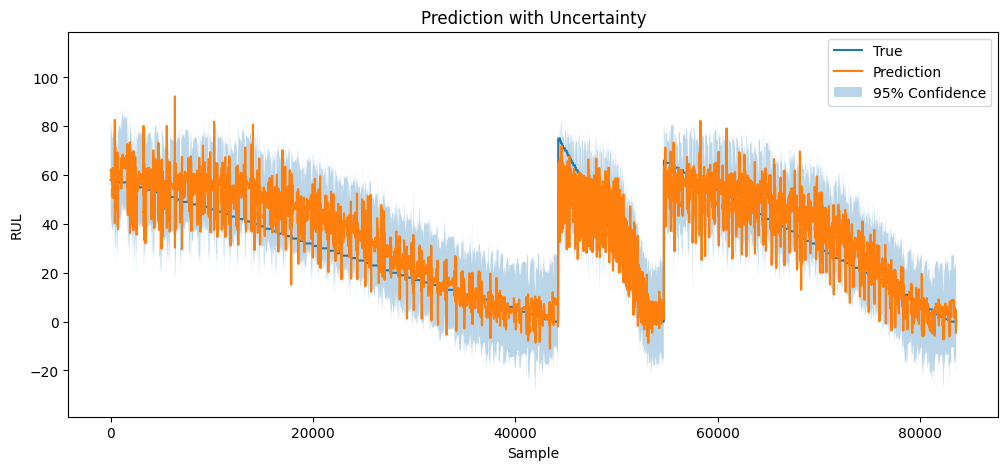

Configuration: lr: 0.001, inducing_points: 400, batch_size: 512
num_inducing: 400
TRAINING SVGP MODEL
Training samples: 291501
Inducing points: 400
Epoch    0 | Train ELBO loss: 992.6291 | Val RMSE: 30.6098
Epoch    5 | Train ELBO loss: 118.5052 | Val RMSE: 18.5462
Epoch   10 | Train ELBO loss: 51.5588 | Val RMSE: 15.8603
Epoch   15 | Train ELBO loss: 26.6015 | Val RMSE: 12.4580
Epoch   20 | Train ELBO loss: 15.1576 | Val RMSE: 9.8546
Epoch   25 | Train ELBO loss: 9.9972 | Val RMSE: 7.8961
Epoch   30 | Train ELBO loss: 7.3885 | Val RMSE: 7.1798
Epoch   35 | Train ELBO loss: 6.0354 | Val RMSE: 7.1419
Epoch   40 | Train ELBO loss: 5.2645 | Val RMSE: 6.5512
Epoch   45 | Train ELBO loss: 4.7717 | Val RMSE: 6.5479
Epoch   50 | Train ELBO loss: 4.4424 | Val RMSE: 6.1093
Epoch   55 | Train ELBO loss: 4.2213 | Val RMSE: 6.4879
Epoch   60 | Train ELBO loss: 4.0685 | Val RMSE: 6.2437
Epoch   65 | Train ELBO loss: 3.9494 | Val RMSE: 6.0522
Epoch   70 | Train ELBO loss: 3.8589 | Val RMSE: 5.9512
E

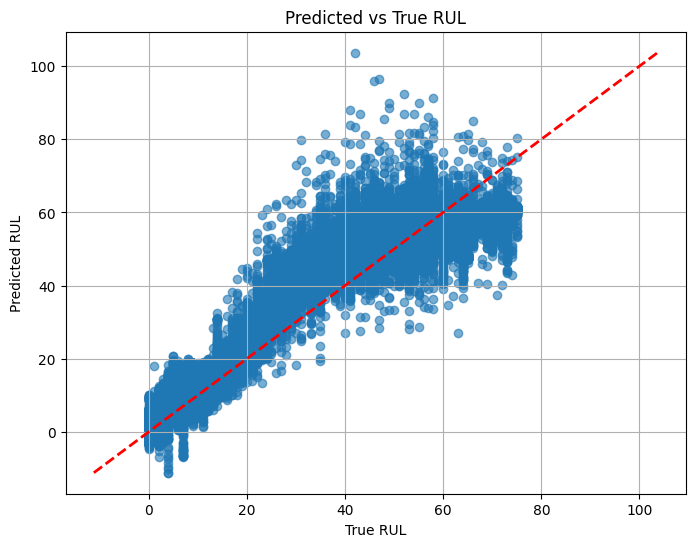

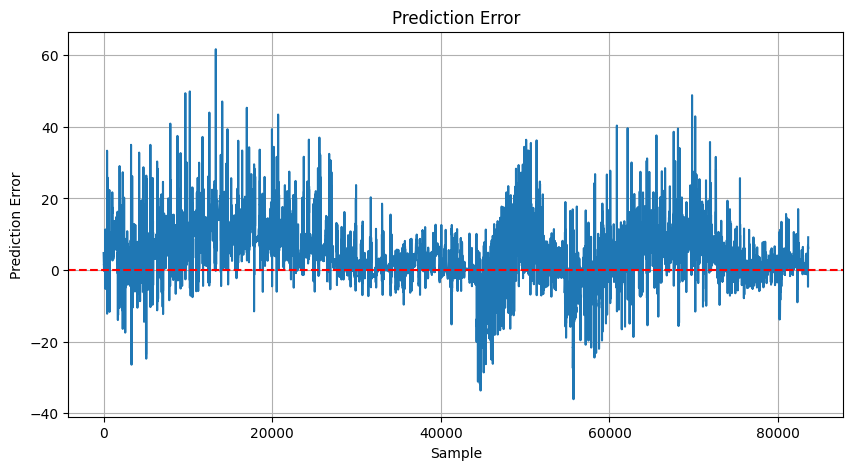

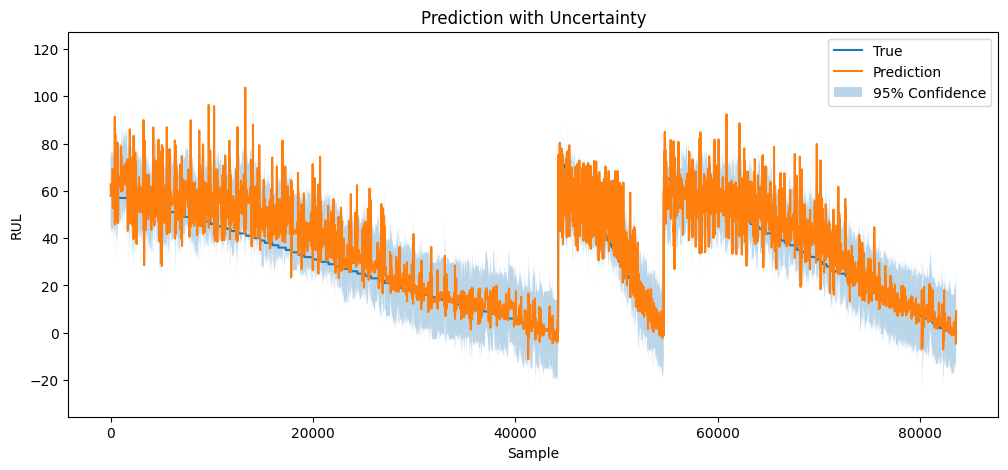

Configuration: lr: 0.0005, inducing_points: 1000, batch_size: 512
num_inducing: 1000
TRAINING SVGP MODEL
Training samples: 291501
Inducing points: 1000
Epoch    0 | Train ELBO loss: 1180.2998 | Val RMSE: 35.3815
Epoch    5 | Train ELBO loss: 166.2384 | Val RMSE: 18.6734
Epoch   10 | Train ELBO loss: 79.6553 | Val RMSE: 15.7775
Epoch   15 | Train ELBO loss: 44.3822 | Val RMSE: 13.6003
Epoch   20 | Train ELBO loss: 26.0226 | Val RMSE: 11.0838
Epoch   25 | Train ELBO loss: 16.8943 | Val RMSE: 8.9702
Epoch   30 | Train ELBO loss: 12.1827 | Val RMSE: 7.7856
Epoch   35 | Train ELBO loss: 9.4248 | Val RMSE: 7.3456
Epoch   40 | Train ELBO loss: 7.7292 | Val RMSE: 7.0536
Epoch   45 | Train ELBO loss: 6.6469 | Val RMSE: 6.8883
Epoch   50 | Train ELBO loss: 5.9210 | Val RMSE: 6.9009
Epoch   55 | Train ELBO loss: 5.4178 | Val RMSE: 6.2168
Epoch   60 | Train ELBO loss: 5.0517 | Val RMSE: 6.2653
Epoch   65 | Train ELBO loss: 4.7762 | Val RMSE: 6.0861
Epoch   70 | Train ELBO loss: 4.5632 | Val RMSE: 

In [ ]:
search_space = [
    {"lr": 1e-2, "inducing_points": 400, "batch_size": 512},
    {"lr": 1e-3, "inducing_points": 400, "batch_size": 512},
    {"lr": 5e-4, "inducing_points": 1000, "batch_size": 512},
    {"lr": 1e-4, "inducing_points": 400, "batch_size": 1024},
]

best_val_rmse = float("inf")
best_config = None
criterion = nn.MSELoss()
for config in search_space:

    print(f'Configuration: lr: {config["lr"]}, inducing_points: {config["inducing_points"]}, batch_size: {config["batch_size"]}')


    X_train_gp = X_windows_train.mean(axis=1)
    X_val_gp   = X_windows_val.mean(axis=1)
    X_test_gp  = X_windows_test.mean(axis=1)

    results = run_svgp_pipeline(
        config["inducing_points"], config["lr"], config["batch_size"],
        X_train_gp, Y_windows_train,
        X_val_gp, Y_windows_val,
        X_test_gp, Y_windows_test
    )

    plot_predictions_gp(Y_windows_test, results['test_mean'])
    plot_errors(Y_windows_test, results['test_mean'])
    plot_uncertainty(
        Y_windows_test,
        results['test_mean'],
        results['test_std']
    )

Configuration: lr: 0.01, inducing_points: 400, batch_size: 512
num_inducing: 400
TRAINING SVGP MODEL
Training samples: 291501
Inducing points: 400
Epoch    0 | Train ELBO loss: 264.9861 | Val RMSE: 17.2900
Epoch    5 | Train ELBO loss: 17.8469 | Val RMSE: 8.7508
Epoch   10 | Train ELBO loss: 9.5632 | Val RMSE: 7.9192
Epoch   15 | Train ELBO loss: 6.7365 | Val RMSE: 7.0619
Epoch   20 | Train ELBO loss: 5.1765 | Val RMSE: 9.1771
Epoch   25 | Train ELBO loss: 4.3939 | Val RMSE: 8.3698
Epoch   30 | Train ELBO loss: 4.0174 | Val RMSE: 6.6208
Epoch   35 | Train ELBO loss: 3.8026 | Val RMSE: 8.9051
Epoch   40 | Train ELBO loss: 3.7290 | Val RMSE: 8.4903
Epoch   45 | Train ELBO loss: 3.7016 | Val RMSE: 8.7057
Epoch   50 | Train ELBO loss: 3.7029 | Val RMSE: 7.3067
Epoch   55 | Train ELBO loss: 3.6949 | Val RMSE: 6.4872
Epoch   60 | Train ELBO loss: 3.7012 | Val RMSE: 8.0335
Early stopping at epoch 64
✓ Training completed in 419.58s

VALIDATION RESULTS
  RMSE: 6.3144
  NASA Score: 37457.82

TES

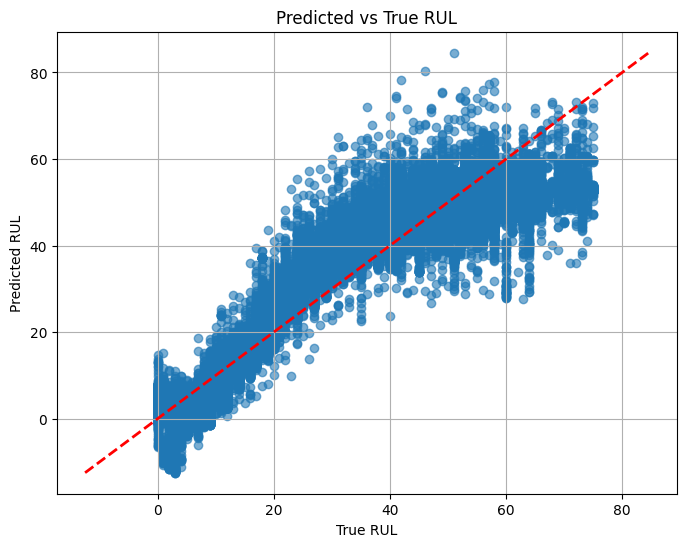

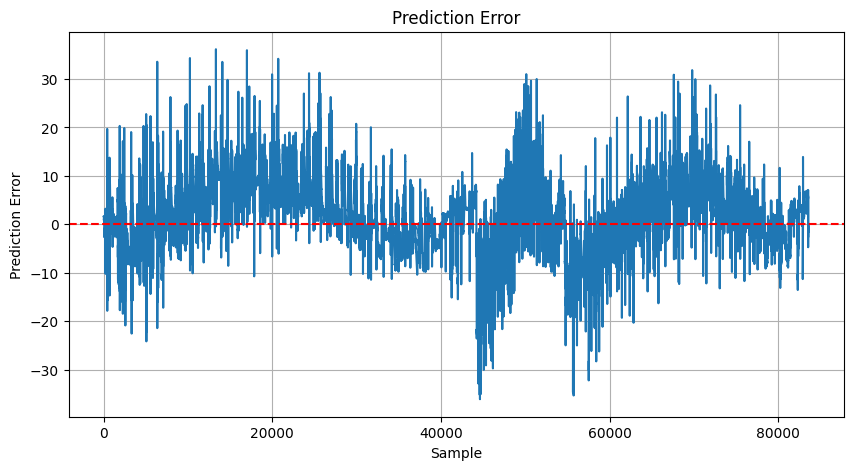

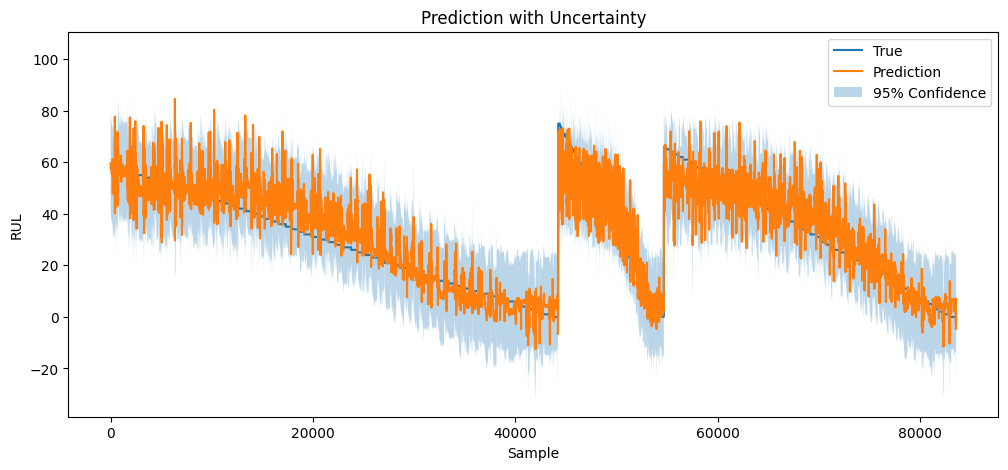

Configuration: lr: 0.001, inducing_points: 400, batch_size: 512
num_inducing: 400
TRAINING SVGP MODEL
Training samples: 291501
Inducing points: 400
Epoch    0 | Train ELBO loss: 991.8238 | Val RMSE: 30.4677
Epoch    5 | Train ELBO loss: 120.4369 | Val RMSE: 18.5405
Epoch   10 | Train ELBO loss: 51.7834 | Val RMSE: 15.4474
Epoch   15 | Train ELBO loss: 26.8442 | Val RMSE: 12.4744
Epoch   20 | Train ELBO loss: 13.9398 | Val RMSE: 8.7845
Epoch   25 | Train ELBO loss: 9.3448 | Val RMSE: 7.6976
Epoch   30 | Train ELBO loss: 7.1070 | Val RMSE: 7.0984
Epoch   35 | Train ELBO loss: 5.8968 | Val RMSE: 6.8815
Epoch   40 | Train ELBO loss: 5.1672 | Val RMSE: 6.3367
Epoch   45 | Train ELBO loss: 4.7118 | Val RMSE: 6.5218
Epoch   50 | Train ELBO loss: 4.4147 | Val RMSE: 6.1166
Epoch   55 | Train ELBO loss: 4.2069 | Val RMSE: 6.1646
Epoch   60 | Train ELBO loss: 4.0490 | Val RMSE: 5.7333
Epoch   65 | Train ELBO loss: 3.9366 | Val RMSE: 6.1273
Epoch   70 | Train ELBO loss: 3.8551 | Val RMSE: 6.1961
E

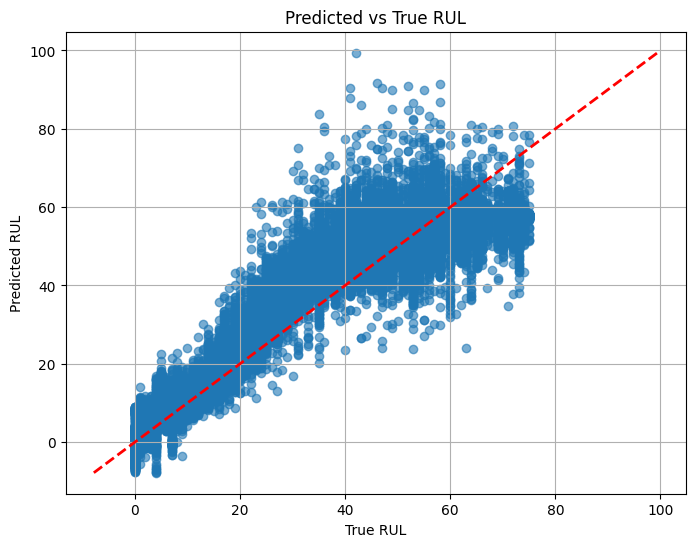

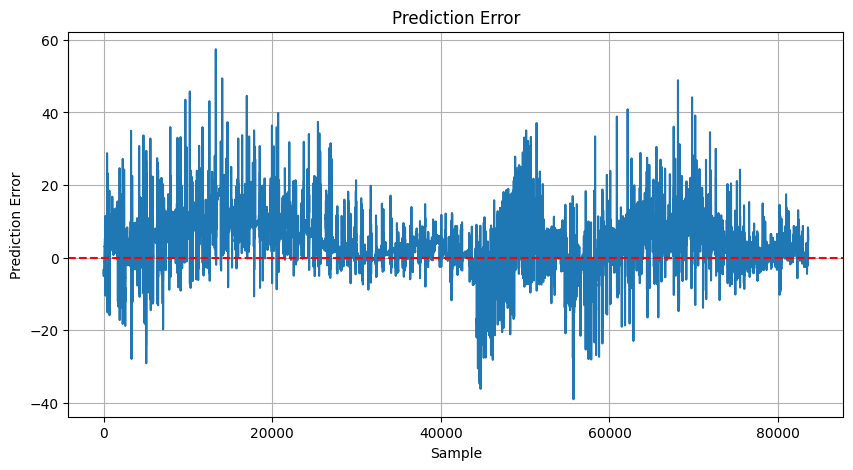

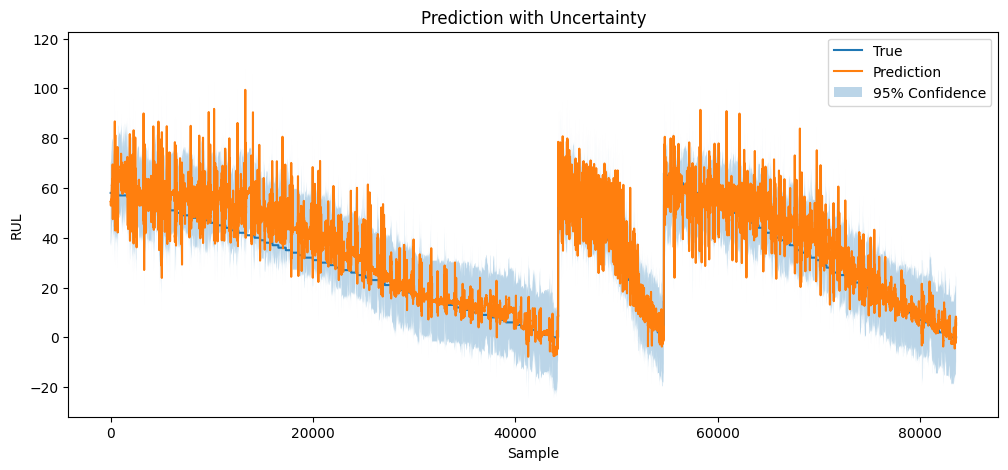

Configuration: lr: 0.0005, inducing_points: 1000, batch_size: 512
num_inducing: 1000
TRAINING SVGP MODEL
Training samples: 291501
Inducing points: 1000
Epoch    0 | Train ELBO loss: 1178.3422 | Val RMSE: 35.2974
Epoch    5 | Train ELBO loss: 167.1704 | Val RMSE: 18.6963
Epoch   10 | Train ELBO loss: 80.2807 | Val RMSE: 15.9184
Epoch   15 | Train ELBO loss: 43.9001 | Val RMSE: 12.9981
Epoch   20 | Train ELBO loss: 25.6946 | Val RMSE: 10.3470
Epoch   25 | Train ELBO loss: 16.7734 | Val RMSE: 9.0114
Epoch   30 | Train ELBO loss: 11.9797 | Val RMSE: 7.7278
Epoch   35 | Train ELBO loss: 9.2717 | Val RMSE: 7.1480
Epoch   40 | Train ELBO loss: 7.6193 | Val RMSE: 6.9373
Epoch   45 | Train ELBO loss: 6.5582 | Val RMSE: 6.6181
Epoch   50 | Train ELBO loss: 5.8377 | Val RMSE: 6.6277
Epoch   55 | Train ELBO loss: 5.3470 | Val RMSE: 6.2484
Epoch   60 | Train ELBO loss: 5.0002 | Val RMSE: 6.0944
Epoch   65 | Train ELBO loss: 4.7408 | Val RMSE: 5.8586
Epoch   70 | Train ELBO loss: 4.5374 | Val RMSE: 

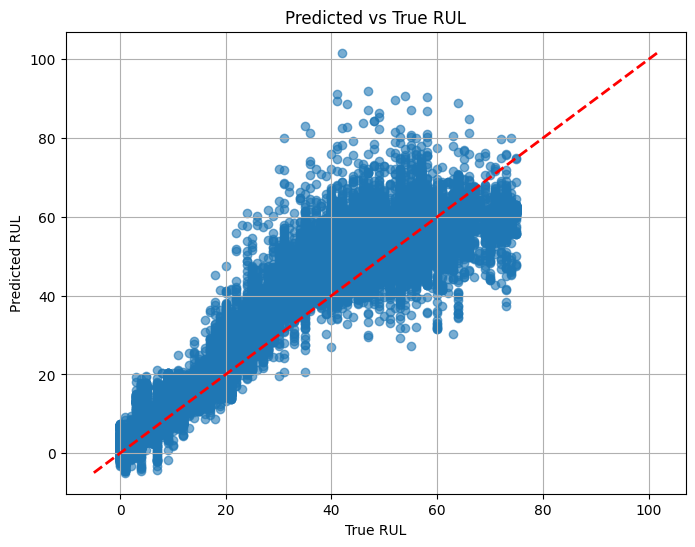

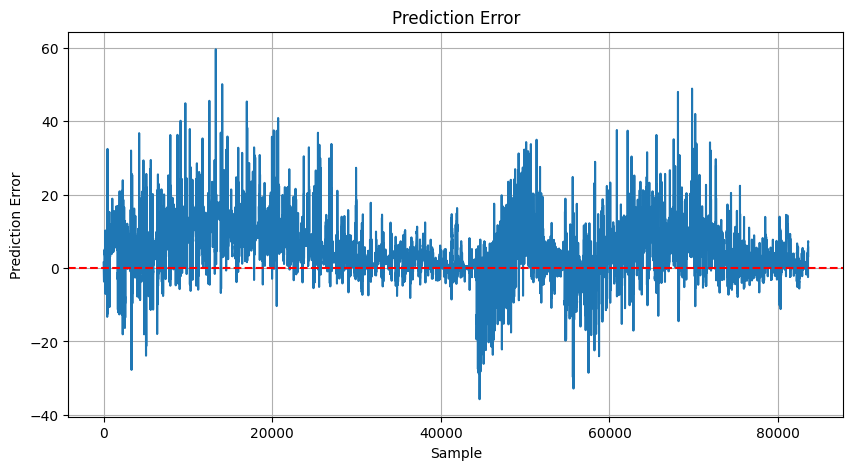

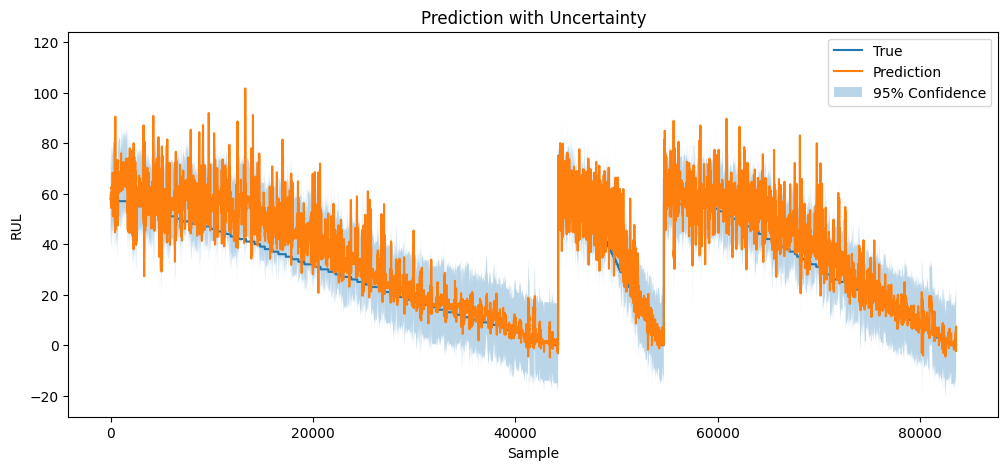

Configuration: lr: 0.0001, inducing_points: 400, batch_size: 1024
num_inducing: 400
TRAINING SVGP MODEL
Training samples: 291501
Inducing points: 400
Epoch    0 | Train ELBO loss: 1389.7001 | Val RMSE: 40.0436
Epoch    5 | Train ELBO loss: 1147.0733 | Val RMSE: 37.8152
Epoch   10 | Train ELBO loss: 943.9867 | Val RMSE: 35.5895
Epoch   15 | Train ELBO loss: 774.8883 | Val RMSE: 33.3378
Epoch   20 | Train ELBO loss: 631.2700 | Val RMSE: 31.0325
Epoch   25 | Train ELBO loss: 510.2430 | Val RMSE: 28.7211
Epoch   30 | Train ELBO loss: 410.2608 | Val RMSE: 26.4948
Epoch   35 | Train ELBO loss: 329.9248 | Val RMSE: 24.4729
Epoch   40 | Train ELBO loss: 267.7148 | Val RMSE: 22.7924
Epoch   45 | Train ELBO loss: 221.7248 | Val RMSE: 21.5826
Epoch   50 | Train ELBO loss: 189.4681 | Val RMSE: 20.8947
Epoch   55 | Train ELBO loss: 167.5019 | Val RMSE: 20.6172
Epoch   60 | Train ELBO loss: 151.4464 | Val RMSE: 20.4585
Epoch   65 | Train ELBO loss: 137.8596 | Val RMSE: 20.3343
Epoch   70 | Train ELB

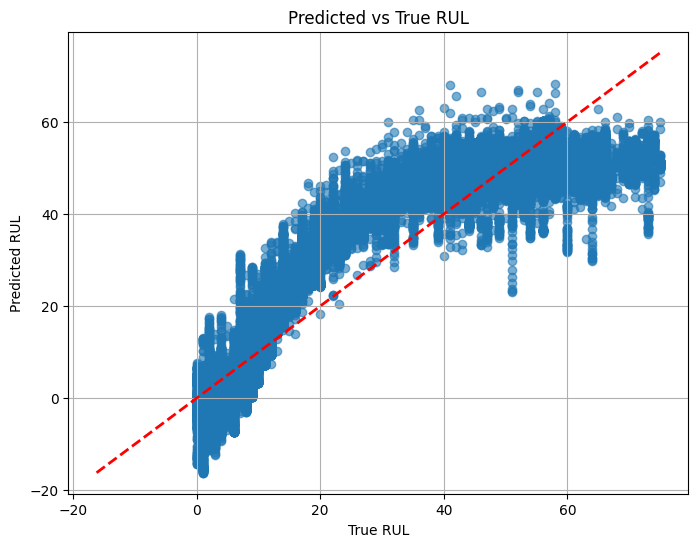

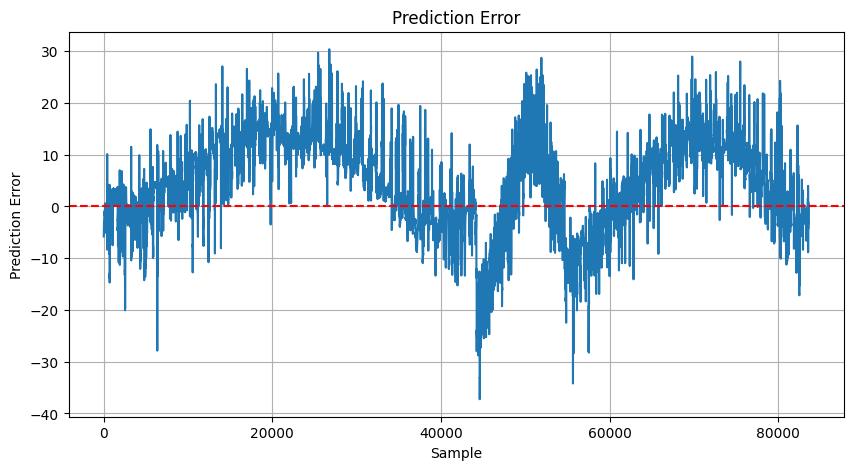

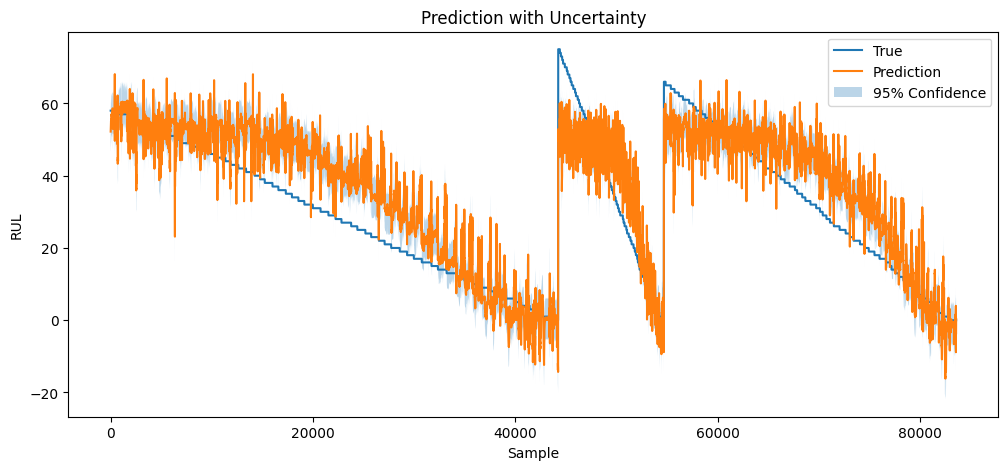

In [ ]:
search_space = [
    {"lr": 1e-2, "inducing_points": 400, "batch_size": 512},
    {"lr": 1e-3, "inducing_points": 400, "batch_size": 512},
    {"lr": 5e-4, "inducing_points": 1000, "batch_size": 512},
    {"lr": 1e-4, "inducing_points": 400, "batch_size": 1024},
]

best_val_rmse = float("inf")
best_config = None
criterion = nn.MSELoss()
for config in search_space:

    print(f'Configuration: lr: {config["lr"]}, inducing_points: {config["inducing_points"]}, batch_size: {config["batch_size"]}')


    X_train_gp = X_windows_train.mean(axis=1)
    X_val_gp   = X_windows_val.mean(axis=1)
    X_test_gp  = X_windows_test.mean(axis=1)

    results = run_svgp_pipeline(
        config["inducing_points"], config["lr"], config["batch_size"],
        X_train_gp, Y_windows_train,
        X_val_gp, Y_windows_val,
        X_test_gp, Y_windows_test
    )

    plot_predictions_gp(Y_windows_test, results['test_mean'])
    plot_errors(Y_windows_test, results['test_mean'])
    plot_uncertainty(
        Y_windows_test,
        results['test_mean'],
        results['test_std']
    )